In [14]:
import networkx as nx
import pandas as pd
import urllib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import ast
import json
from tqdm import tqdm

In [ ]:
# with urllib.request.urlopen("https://raw.githubusercontent.com/Somon8/social_graphs_25/main/final-project/party_colors.json") as response:
#     party_colors = json.load(response)

In [5]:
with urllib.request.urlopen("https://raw.githubusercontent.com/Somon8/social_graphs_25/main/final-project/voting-data/df_votes_enriched.csv") as response:
    df = pd.read_csv(response)
    

In [6]:
df.head(2)

,voting_id,party,politician,vote_type,Period,vedtaget,Møde.dato,topics_simple
0,1,Enhedslisten,Frank Aaen,1,68,True,2014-09-09 09:00:00,['økonomi']
1,1,Socialdemokratiet,Nicolai Wammen,3,68,True,2014-09-09 09:00:00,['økonomi']


In [7]:
df["topics_simple"] = df["topics_simple"].apply(ast.literal_eval) #It´s a god damn string, not a list. Convert it to list
df_exp = df.explode("topics_simple")
df_exp["topics_simple"].unique()

array(['økonomi', 'klima', 'uddannelse', 'retspolitik', 'social',
       'forsvar', 'andet', 'transport', 'immigration', 'udenrigspolitik',
       'bolig', 'sundhed', nan], dtype=object)

In [8]:
print(df['Period'].unique())

[68 67 69 66 65 70 71]


In [ ]:
#WE could also already have filtered the dataframe here by theme or something like that. It's probably the smartest thing to do.
def build_g_df_from_df(df):
    graph_edges = []
    politician_list = df['politician'].unique()
    for idx, politician in enumerate(tqdm(politician_list)):

        df_pol = df[df['politician'] == politician][['voting_id', 'vote_type', 'party', 'Period', 'topics_simple']]

        for other_politician in politician_list[idx+1:]: #Look at remaining politicians to avoid double work
            df_other = df[df['politician'] == other_politician][['voting_id', 'vote_type', 'party']]
            
            total_df = df_pol.merge(df_other, on='voting_id', how='inner') #Count how many voting_id's they share
            agree_df = df_pol.merge(df_other, on=['voting_id', 'vote_type'], how='inner') #Count share where they also voted the same
            total = len(total_df)
            agree = len(agree_df)

            agree_percent = agree / total if total > 0 else 0
            edge = {'source': politician
                   , 'target': other_politician
                   , 'weight': agree_percent
                   , 'total_votes_agreed': agree
                   , 'total_votes_shared': total
                   , 'source_party' : df_pol['party'].iloc[0]
                   , 'target_party' : df_other['party'].iloc[0]
                   , 'period' : df_pol['Period'].iloc[0]
                   , 'topic' :df_pol['topics_simple'].iloc[0]
                   }
            graph_edges.append(edge)
    g_df = pd.DataFrame(graph_edges)
    return g_df

def build_edges_for_multiple_periods(df, topic = None, topic_col = "topics_simple"):
    filtered_df = df[df['vote_type'] != 3]
    if topic:
        df_exp = filtered_df.explode(topic_col) #Explode if we are calculating it for a specific topic
        filtered_df = df_exp[df_exp[topic_col] == topic] #Limit the dataframe to only the chosen topic
    else:
        topic = "all_topics"
    all_periods = filtered_df['Period'].unique()
    all_votes_on_topic = pd.DataFrame()
    for period in all_periods:
        print(f"Creating df for period {period} on topic {topic}", end = " ")
        #Define the df
        df_for_period = filtered_df[filtered_df['Period'] == period]
        g_df_for_period = build_g_df_from_df(df_for_period)
        all_votes_on_topic = pd.concat([all_votes_on_topic, g_df_for_period], ignore_index= True)
        # all_votes_on_topic.append(g_df_for_period, ignore_index = True)
    all_votes_on_topic.to_csv(f"./voting-data/politician_edges_{topic}.csv", index = False)
    return all_votes_on_topic

In [31]:
g_df_klima = build_edges_for_multiple_periods(df_exp)

Creating df for period 68 on topic all_topics 

100%|██████████| 125/125 [02:10<00:00,  1.04s/it]


Creating df for period 67 on topic all_topics 

100%|██████████| 120/120 [01:58<00:00,  1.02it/s]


Creating df for period 69 on topic all_topics 

...

100%|██████████| 105/105 [00:41<00:00,  2.52it/s]


Creating df for period 70 on topic all_topics 

100%|██████████| 108/108 [02:09<00:00,  1.20s/it]


Creating df for period 71 on topic all_topics 

100%|██████████| 123/123 [02:08<00:00,  1.05s/it]


# Everything below here needs to be moved to a new cell

In [ ]:
# all_parties = list(g_df['source_party'].unique()) + list(g_df['target_party'].unique())
# unique_parties = list(set(all_parties))
# for idx, party in enumerate(unique_parties):
#     for other_party in unique_parties[idx+1:]:
#         #Find the sub-dataframe we should calculate it on
#         mask_source = (g_df['source_party'] == party) & (g_df['target_party'] == other_party)
#         mask_target = (g_df['source_party'] == other_party) & (g_df['target_party'] == party)
#         mask = mask_source | mask_target
#         relevant_df = g_df[mask]

#         #Calculate the agreement
#         party_votes_agreed = relevant_df["total_votes_agreed"].sum()
#         party_votes_shared = relevant_df["total_votes_shared"].sum()

#         party_agree_percentage = party_votes_agreed / party_votes_shared
#         print(party, other_party, party_agree_percentage)


#         # print(party, other_party, shared_votes)

        

#         # if not g_df[mask].empty:
#         #     continue
#         # edge = {'source': f'Party_{party}'
#         #        , 'target': f'Party_{other_party}'
#         #        , 'weight': 0
#         #        , 'total_shared_votes': 0
#         #        , 'source_party' : party
#         #        , 'target_party' : other_party
#         #        }
#         # g_df = pd.concat([g_df, pd.DataFrame([edge])], ignore_index=True)
    


Sambandsflokkurin Venstre 1.0
Sambandsflokkurin Det Konservative Folkeparti 1.0
Sambandsflokkurin Moderaterne nan
Sambandsflokkurin Dansk Folkeparti 1.0
Sambandsflokkurin Liberal Alliance nan
Sambandsflokkurin Enhedslisten 1.0
Sambandsflokkurin Danmarksdemokraterne 1.0
Sambandsflokkurin Alternativet 1.0
Sambandsflokkurin Socialistisk Folkeparti 1.0
Sambandsflokkurin Uden for folketingsgrupperne 1.0
Sambandsflokkurin Socialdemokratiet 1.0
Sambandsflokkurin Radikale Venstre 1.0
Venstre Det Konservative Folkeparti 0.8866666666666667
Venstre Moderaterne 1.0
Venstre Dansk Folkeparti 0.7105478331970564
Venstre Liberal Alliance 0.7908461947844598
Venstre Enhedslisten 0.4717969935181354
Venstre Danmarksdemokraterne 0.7577237299276928
Venstre Alternativet 0.48040313549832026
Venstre Socialistisk Folkeparti 0.572855464159812
Venstre Uden for folketingsgrupperne 0.7196048632218845
Venstre Socialdemokratiet 0.7115578734858681
Venstre Radikale Venstre 0.6222253245846713
Det Konservative Folkeparti 

C:\Users\ThorNørgaardEriksen\AppData\Local\Temp\ipykernel_38232\2903279605.py:15: RuntimeWarning: invalid value encountered in scalar divide
  party_agree_percentage = party_votes_agreed / party_votes_shared


In [30]:
g_df['target_party'].unique()

array(['Venstre', 'Socialdemokratiet', 'Socialistisk Folkeparti',
       'Enhedslisten', 'Danmarksdemokraterne',
       'Uden for folketingsgrupperne', 'Radikale Venstre',
       'Det Konservative Folkeparti', 'Alternativet', 'Dansk Folkeparti',
       'Sambandsflokkurin', 'Liberal Alliance', 'Moderaterne'],
      dtype=object)

In [ ]:
# #Get the coloring going
# politician_colors = {}
# for politician in G.nodes:
#     party = df[df['politician'] == politician]['party'].iloc[0]
#     try:
#         politician_colors[politician] = party_colors[party]
#     except:
#         politician_colors[politician] = '#808080'
#         print(f"No color found for {politician} in {party}, assigning gray.")

# print(politician_colors)

No color found for Liselott Blixt in Uden for folketingsgrupperne, assigning gray.
No color found for Kristian Thulesen Dahl in Uden for folketingsgrupperne, assigning gray.
No color found for Marie Krarup in Uden for folketingsgrupperne, assigning gray.
No color found for Edmund Joensen in Sambandsflokkurin, assigning gray.
No color found for Jens Rohde in Uden for folketingsgrupperne, assigning gray.
No color found for Simon Emil Ammitzbøll-Bille in Uden for folketingsgrupperne, assigning gray.
No color found for Naser Khader in Uden for folketingsgrupperne, assigning gray.
{'Nicolai Wammen': '#E3515D', 'Karsten Lauritzen': '#005392', 'Astrid Krag': '#E3515D', 'Pia Olsen Dyhr': '#9C1D2E', 'Henning Hyllested': '#E6801A', 'Peter Skaarup': '#00746A', 'Erling Bonnesen': '#005392', 'Liselott Blixt': '#808080', 'Rasmus Helveg Petersen': '#EB4295', 'Pernille Skipper': '#E6801A', 'Karen Ellemann': '#005392', 'Kristian Thulesen Dahl': '#808080', 'Marie Krarup': '#808080', 'Torsten Schack Pede

5778 3228


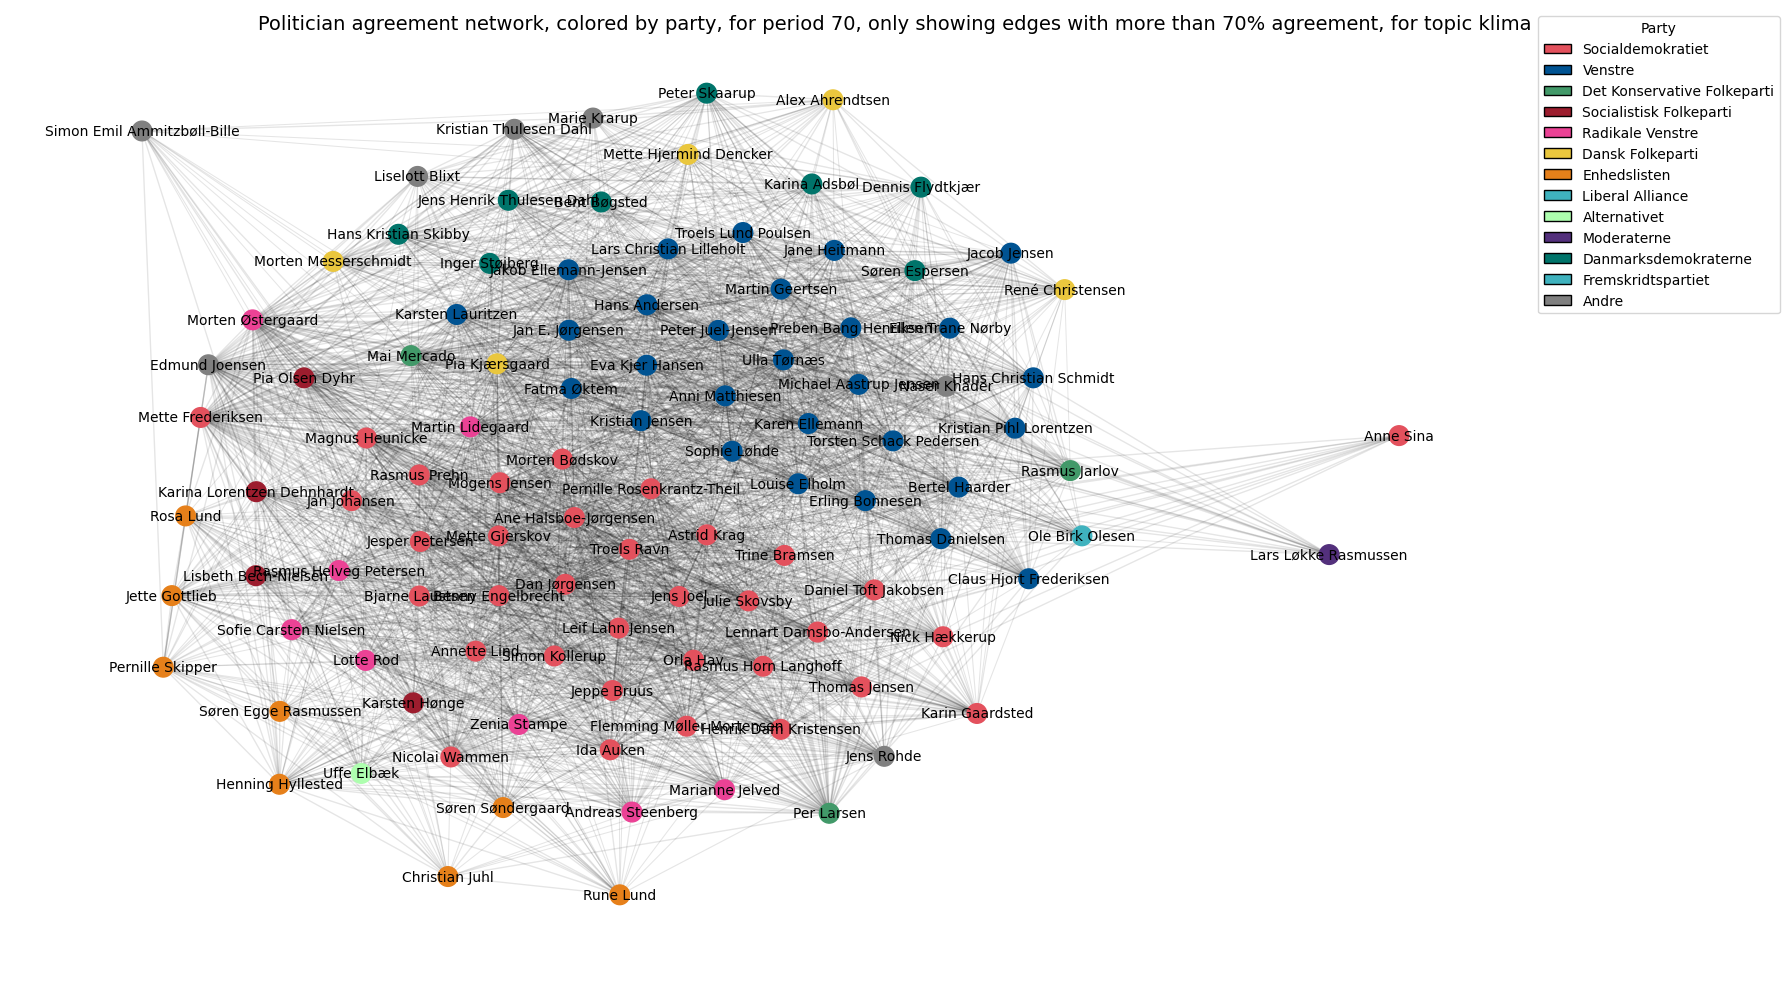

In [ ]:

# def edgelist_and_graph_to_visualization(edgelist, G, df):
#     figure, axs = plt.subplots(1,1,figsize = (18,10)) #Width, Height


#     # Some arguments for the visualization
#     period = df['Period'].unique() #We should maybe convert this to a time-period instea
#     topic = df['topics_simple'].unique()


#     #NETWULF FOR DRAWING GRAPHS could be interesting. Danny has worked with it before
#     pos = nx.forceatlas2_layout(G
#                                             , seed = 42
#                                             , weight = "weight"
#                                             , max_iter = 5000
#                                             )

#     # nodes
#     agreement_threshold = 0.7
#     df_draw = g_df[g_df['weight'] > agreement_threshold]

#     print(len(g_df), len(df_draw))

#     #Get the edges and widths to draw
#     edges = list(zip(df_draw['source'], df_draw['target']))
#     edge_widths = df_draw['weight'].tolist()


#     nx.draw_networkx_nodes(G, pos, node_size=200, ax = axs, node_color = [politician_colors[node] for node in G.nodes()])

#     # edges
#     nx.draw_networkx_edges(G, pos, edgelist=edges, width=[w * 1 for w in edge_widths], alpha = 0.1, ax = axs)


#     # node labels
#     nx.draw_networkx_labels(G, pos, font_size=10, ax = axs)

#     # Build legend: only parties that appear in politician_colors
#     used_colors = set(politician_colors.values())

#     legend_handles = []
#     for party, color in party_colors.items():
#         if color in used_colors:
#             legend_handles.append(Patch(facecolor=color, edgecolor='black', label=party))

#     axs.legend(handles=legend_handles, title="Party", loc="upper left", bbox_to_anchor=(1, 1))



#     # ax.margins(0.08)
#     plt.axis("off")
#     plt.tight_layout()
#     plt.suptitle(f"Politician agreement network, colored by party, for period {period[0]}, only showing edges with more than {agreement_threshold*100:.0f}% agreement, for topic {topic[0]}", fontsize = 14)
#     # plt.title(f"Topic is {topic[0]}")

#     plt.show()

# edgelist_and_graph_to_visualization(g_df, G, df = df_cleaned)
